# Валидация RBA-модели сессионного фрода

`python/train.py` обучает модель и выгружает артефакты, но не валидирует режим
оценки: гиперпараметры захардкожены, сплит случайный, нет калибровки и
error-analysis. Этот ноутбук закрывает пробел, оставаясь в честной рамке
репозитория - доказывается путь подачи и корректность кодов причин, а качество
модели вторично и меряется без прикрас.

Содержание:
1. Режим оценки: случайный сплит против временного.
2. Кривые вместо точек: ROC, PR (с базой), precision/recall от порога.
3. Калибровка вероятностей (reliability diagram).
4. Базлайны: логистическая регрессия и простое правило - бьёт ли их ансамбль.
5. Помесячный дрейф.
6. Эффект scale_pos_weight.
7. SHAP beeswarm нативным pred_contrib - тот же механизм, что в проде даёт
   per-decision коды причин, но агрегированный в глобальную картину.

Признаки причинны по времени (новизна и счётчики используют только прошлое
пользователя), поэтому временной сплит на уже посчитанных признаках корректен:
фичи строки теста зависят лишь от её прошлого.

Ноутбук тяжёлый: грузит весь датасет RBA (~31M строк). Рассчитан на машину с
большой памятью (см. README, `make data-rba`).

In [1]:
%matplotlib inline
import pathlib
import sys

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Корень репозитория (ноутбук может запускаться из любого каталога).
ROOT = pathlib.Path.cwd().resolve()
while not (ROOT / "training" / "train.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "training"))
from train import load_rba  # noqa: E402

np.random.seed(708)
DATA = ROOT / "testdata" / "rba-dataset.csv"

In [2]:
# Полная загрузка с таймстампами (несколько минут на 31M строк).
X, y, ts, names, codes = load_rba(str(DATA), "attack")
nfeat = len(names)
month = ts.astype("datetime64[M]")
base_rate = float(y.mean())
print(f"строк={len(X):,} признаков={nfeat} attack_rate={base_rate:.4f}")
print(f"период: {ts.min()} .. {ts.max()}")
print("признаки:", names)

строк=31,269,264 признаков=12 attack_rate=0.0990
период: 2020-02-03T12:43:30.772000000 .. 2021-02-28T23:59:58.756000000
признаки: ['rtt_ms', 'login_successful', 'hour', 'dow', 'n_prior_logins', 'secs_since_last', 'is_new_country', 'is_new_city', 'is_new_asn', 'is_new_os', 'is_new_browser', 'is_new_device']


In [3]:
# Общие параметры обучения (как в train.py) и хелперы.
PARAMS = dict(
    objective="binary", num_leaves=31, learning_rate=0.05, min_data_in_leaf=50,
    feature_fraction=1.0, bagging_fraction=1.0, deterministic=True,
    force_row_wise=True, num_threads=8, seed=708, verbose=-1,
)
N_TRAIN, N_TEST = 3_000_000, 200_000
ALL = np.arange(len(X))


def fit(idx_tr, **over):
    return lgb.train({**PARAMS, **over}, lgb.Dataset(X[idx_tr], label=y[idx_tr]), num_boost_round=200)


def sub(idx, n):
    return idx if len(idx) <= n else np.random.choice(idx, n, replace=False)


def margin(model, idx):
    return model.predict(X[idx], raw_score=True)

## 1. Режим оценки: случайный сплит против временного

Случайный сплит перемешивает строки и оптимистичен: в проде модель предсказывает
будущее. Временной сплит (обучение на раннем периоде, тест на позднем) имитирует
этот режим и учитывает дрейф. Обучаем обе модели одинаково, меняем только сплит.

In [4]:
perm = np.random.permutation(len(X))
rnd_test, rnd_train = perm[:N_TEST], sub(perm[N_TEST:], N_TRAIN)

order = np.argsort(ts, kind="stable")
cutoff = ts[order[int(len(order) * 0.85)]]  # порог по 85-му перцентилю времени
early, late = ALL[ts < cutoff], ALL[ts >= cutoff]
tmp_train, tmp_test = sub(early, N_TRAIN), sub(late, N_TEST)
print(f"временной порог: {cutoff} | early={len(early):,} late={len(late):,}")

m_rnd, m_tmp = fit(rnd_train), fit(tmp_train)
print(f"{'сплит':10s} {'ROC-AUC':>8s} {'PR-AUC':>7s} {'base':>7s} {'lift=PR/base':>13s}")
for label, model, test in [("случайный", m_rnd, rnd_test), ("временной", m_tmp, tmp_test)]:
    s, yt = margin(model, test), y[test]
    roc, ap, b = roc_auc_score(yt, s), average_precision_score(yt, s), yt.mean()
    print(f"{label:10s} {roc:8.4f} {ap:7.4f} {b:7.4f} {ap / b:13.2f}")
print("ROC-AUC сравним между сплитами; абсолютная PR-AUC - НЕТ (растёт с base). "
      "Сравнимая величина дисбаланса - lift = PR-AUC/base.")

временной порог: 2021-01-05T17:21:26.803000000 | early=26,578,874 late=4,690,390


сплит       ROC-AUC  PR-AUC    base  lift=PR/base
случайный    0.6923  0.1827  0.0981          1.86


временной    0.6813  0.1977  0.1166          1.69
ROC-AUC сравним между сплитами; абсолютная PR-AUC - НЕТ (растёт с base). Сравнимая величина дисбаланса - lift = PR-AUC/base.


**Осторожно с PR-AUC между сплитами.** Average precision механически растёт с
base rate, а у позднего (временного) теста доля атак выше. Поэтому абсолютная
PR-AUC временного сплита может оказаться ВЫШЕ случайного, хотя модель там хуже -
сравнивать напрямую нельзя. Сравнимая величина - **lift = PR-AUC/base**: по нему
временной сплит ниже, что согласуется с просадкой ROC-AUC (ROC от base не зависит
и сравним напрямую). Так что снижение и по ROC, и по lift - это дрейф и режим
"предсказываем будущее", который случайный сплит скрывает.

Дальше всё меряем на честном (временном) тесте.

In [5]:
m, test = m_tmp, tmp_test
s, yt = margin(m, test), y[test]

## 2. Кривые вместо точек

Точка "recall 0.4% при margin>0" пугает, но это лишь одна рабочая точка. Полный
trade-off виден на кривых: ROC, PR (с базовой долей) и precision/recall от порога.
Рабочую точку задают по целевому FPR/recall, а не по дефолтному margin>0.

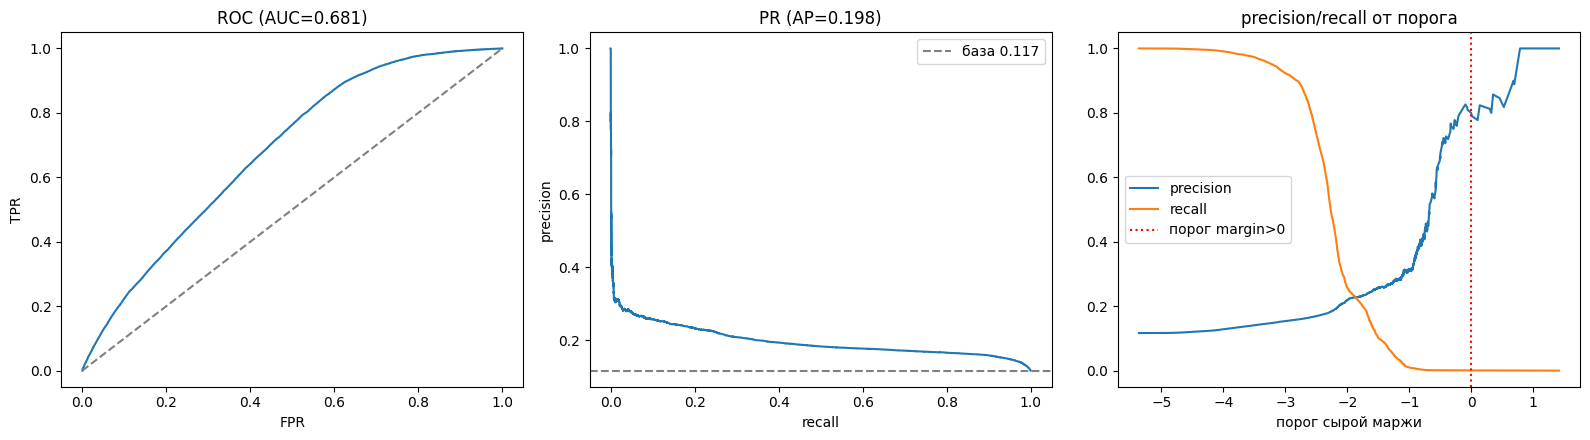

In [6]:
fpr, tpr, _ = roc_curve(yt, s)
prec, rec, thr = precision_recall_curve(yt, s)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].plot(fpr, tpr)
ax[0].plot([0, 1], [0, 1], "--", c="gray")
ax[0].set(title=f"ROC (AUC={roc_auc_score(yt, s):.3f})", xlabel="FPR", ylabel="TPR")
ax[1].plot(rec, prec)
ax[1].axhline(yt.mean(), ls="--", c="gray", label=f"база {yt.mean():.3f}")
ax[1].set(title=f"PR (AP={average_precision_score(yt, s):.3f})", xlabel="recall", ylabel="precision")
ax[1].legend()
ax[2].plot(thr, prec[:-1], label="precision")
ax[2].plot(thr, rec[:-1], label="recall")
ax[2].axvline(0, ls=":", c="r", label="порог margin>0")
ax[2].set(title="precision/recall от порога", xlabel="порог сырой маржи")
ax[2].legend()
plt.tight_layout()
plt.show()

## 3. Калибровка вероятностей

Вероятность = sigmoid(маржа). Reliability diagram показывает, совпадает ли
предсказанная вероятность с фактической долей положительных.

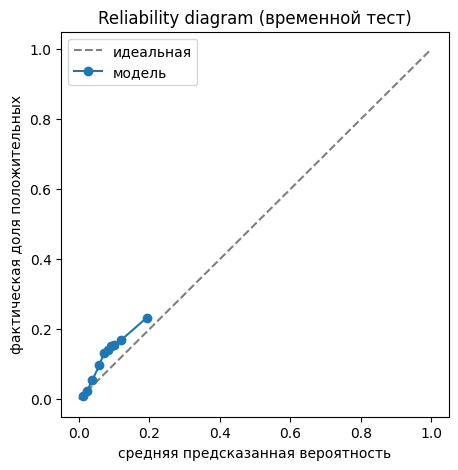

In [7]:
prob = 1.0 / (1.0 + np.exp(-s))
frac_pos, mean_pred = calibration_curve(yt, prob, n_bins=10, strategy="quantile")
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "--", c="gray", label="идеальная")
plt.plot(mean_pred, frac_pos, "o-", label="модель")
plt.xlabel("средняя предсказанная вероятность")
plt.ylabel("фактическая доля положительных")
plt.title("Reliability diagram (временной тест)")
plt.legend()
plt.show()

## 4. Базлайны: бьёт ли их ансамбль

Логистическая регрессия на тех же признаках и простое правило "новое устройство И
долгий перерыв". Если ансамбль не бьёт их заметно - сложная модель не оправдана.

In [8]:
dev_i, gap_i = names.index("is_new_device"), names.index("secs_since_last")


def impute(idx):
    Z = X[idx].astype("float64")
    med = np.nanmedian(Z, axis=0)
    bad = np.where(np.isnan(Z))
    Z[bad] = np.take(med, bad[1])
    return Z


lr_train = sub(tmp_train, 500_000)
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=300, class_weight="balanced"))
lr.fit(impute(lr_train), y[lr_train])
s_lr = lr.decision_function(impute(test))

T = 7 * 24 * 3600  # перерыв > 7 дней
rule = ((X[test][:, dev_i] == 1) & (X[test][:, gap_i] > T)).astype(int)
rp, rr = precision_score(yt, rule, zero_division=0), recall_score(yt, rule, zero_division=0)

print(f"ансамбль   ROC-AUC={roc_auc_score(yt, s):.4f}  PR-AUC={average_precision_score(yt, s):.4f}")
print(f"логистика  ROC-AUC={roc_auc_score(yt, s_lr):.4f}  PR-AUC={average_precision_score(yt, s_lr):.4f}")
print(f"правило 'новое устройство И перерыв>7д': precision={rp:.3f} recall={rr:.3f}")
if rr > 0:  # ансамбль при том же recall, что у правила
    si = np.argsort(-s)
    k = int(np.searchsorted(np.cumsum(yt[si]), rr * yt.sum()))
    thr_match = s[si][min(k, len(s) - 1)]
    pred = s >= thr_match
    print(f"ансамбль при recall~{recall_score(yt, pred, zero_division=0):.3f}: "
          f"precision={precision_score(yt, pred, zero_division=0):.3f} (правило {rp:.3f})")

ансамбль   ROC-AUC=0.6813  PR-AUC=0.1977
логистика  ROC-AUC=0.6389  PR-AUC=0.1714
правило 'новое устройство И перерыв>7д': precision=0.013 recall=0.002
ансамбль при recall~0.002: precision=0.442 (правило 0.013)


## 5. Помесячный дрейф

Модель обучена на раннем периоде. Её AUC и фактическая доля атак по месяцам
показывают, как меняется поток и держится ли качество (граница train/test - линия).

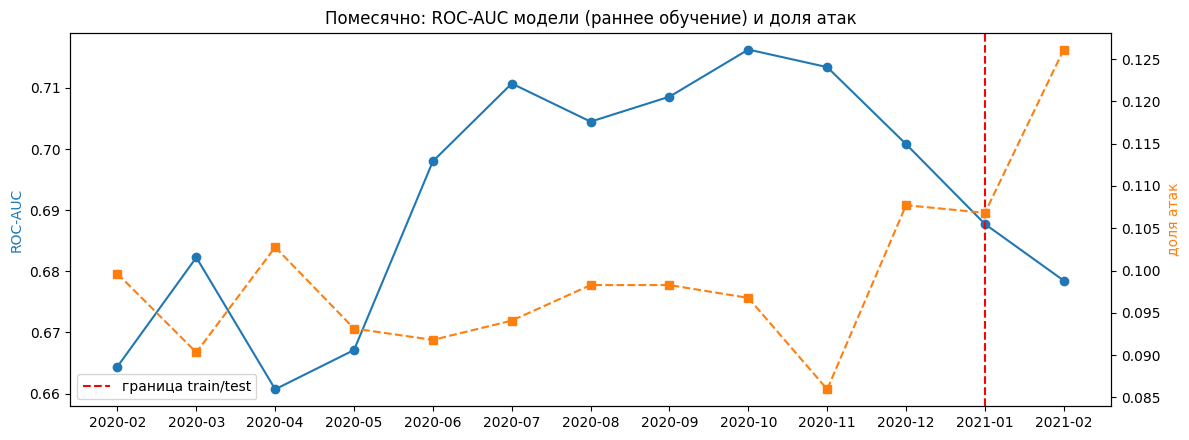

In [9]:
rows = []
for mo in np.unique(month):
    idx = sub(ALL[month == mo], 50_000)
    yt2 = y[idx]
    if 0 < yt2.sum() < len(yt2):
        rows.append((str(mo), roc_auc_score(yt2, margin(m, idx)), float(yt2.mean())))
labels = [r[0] for r in rows]
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(labels, [r[1] for r in rows], "o-", c="C0")
ax1.set_ylabel("ROC-AUC", color="C0")
ax1.axvline(str(cutoff.astype("datetime64[M]")), ls="--", c="r", label="граница train/test")
ax2 = ax1.twinx()
ax2.plot(labels, [r[2] for r in rows], "s--", c="C1")
ax2.set_ylabel("доля атак", color="C1")
ax1.set_title("Помесячно: ROC-AUC модели (раннее обучение) и доля атак")
ax1.legend(loc="lower left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Эффект scale_pos_weight

Дисбаланс примерно 9:1. `scale_pos_weight = neg/pos` меняет масштаб вероятностей
(обычно ломает калибровку), почти не двигая ранжирование (AUC).

scale_pos_weight=9.42
  без веса:  ROC-AUC=0.6813  PR-AUC=0.1977
  с весом:   ROC-AUC=0.6819  PR-AUC=0.1979


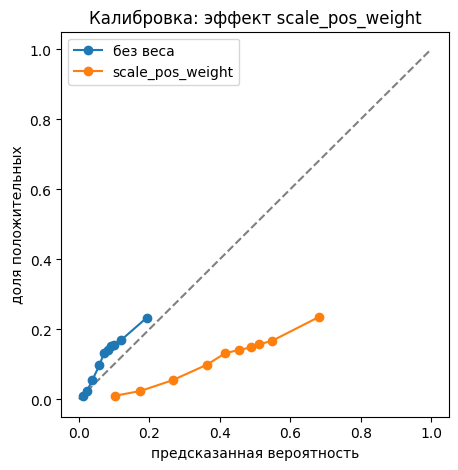

In [10]:
spw = float((y[tmp_train] == 0).sum() / max(1, (y[tmp_train] == 1).sum()))
m_spw = fit(tmp_train, scale_pos_weight=spw)
s_spw = margin(m_spw, test)
print(f"scale_pos_weight={spw:.2f}")
print(f"  без веса:  ROC-AUC={roc_auc_score(yt, s):.4f}  PR-AUC={average_precision_score(yt, s):.4f}")
print(f"  с весом:   ROC-AUC={roc_auc_score(yt, s_spw):.4f}  PR-AUC={average_precision_score(yt, s_spw):.4f}")
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "--", c="gray")
for label, sc in [("без веса", s), ("scale_pos_weight", s_spw)]:
    p = 1.0 / (1.0 + np.exp(-sc))
    fpos, mpred = calibration_curve(yt, p, n_bins=10, strategy="quantile")
    plt.plot(mpred, fpos, "o-", label=label)
plt.xlabel("предсказанная вероятность")
plt.ylabel("доля положительных")
plt.title("Калибровка: эффект scale_pos_weight")
plt.legend()
plt.show()

## 7. SHAP beeswarm (нативный pred_contrib)

Глобальная картина строится тем же путём, что в проде даёт per-decision коды
причин: `C_API_PREDICT_CONTRIB` (здесь `predict(pred_contrib=True)`). Один
механизм, два применения - глобальное понимание модели и per-decision
adverse-action. Точка - вход; по оси X вклад в сырую маржу (>0 толкает к атаке),
цвет - значение признака.

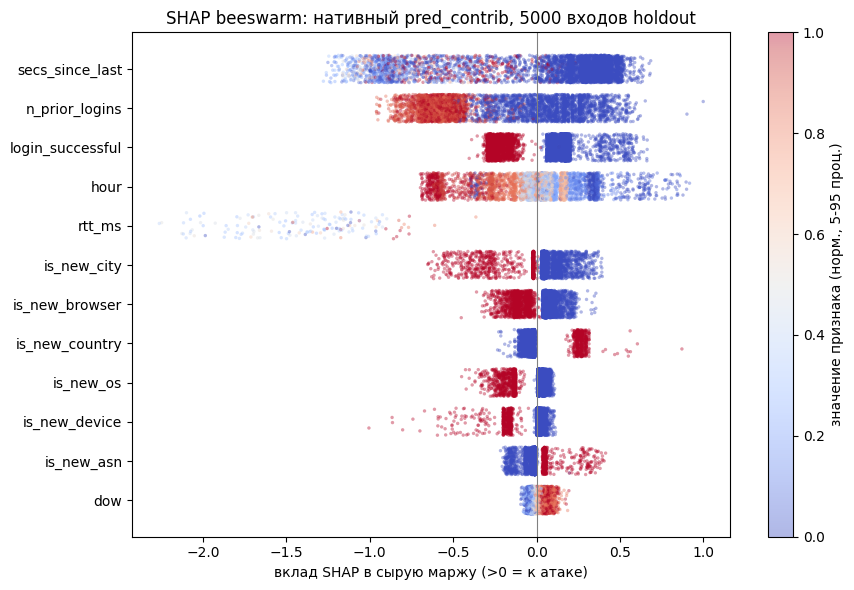

In [11]:
sx = sub(test, 5000)
contrib = m.predict(X[sx], pred_contrib=True)[:, :nfeat]
Xs = X[sx]
order = np.argsort(np.abs(contrib).mean(axis=0))  # снизу вверх по важности
plt.figure(figsize=(9, 6))
sc = None
for yi, fi in enumerate(order):
    cv, fv = contrib[:, fi], Xs[:, fi].astype("float64")
    norm = np.full(len(fv), 0.5)
    fin = np.isfinite(fv)
    if fin.sum() > 1:
        lo, hi = np.nanpercentile(fv[fin], [5, 95])
        if hi > lo:
            norm = np.clip((fv - lo) / (hi - lo), 0.0, 1.0)
    jit = yi + (np.random.rand(len(cv)) - 0.5) * 0.7
    sc = plt.scatter(cv, jit, c=norm, cmap="coolwarm", s=6, alpha=0.4, linewidths=0)
plt.yticks(range(nfeat), [names[i] for i in order])
plt.axvline(0, c="gray", lw=0.8)
plt.xlabel("вклад SHAP в сырую маржу (>0 = к атаке)")
plt.title("SHAP beeswarm: нативный pred_contrib, 5000 входов holdout")
cb = plt.colorbar(sc)
cb.set_label("значение признака (норм., 5-95 проц.)")
plt.tight_layout()
plt.show()

## Итог

- Временной сплит честнее случайного: ниже по ROC-AUC и по lift PR-AUC/base
  (дрейф, режим "предсказываем будущее"). Абсолютную PR-AUC между сплитами не
  сравнивать - она механически растёт с base rate.
- Кривые показывают весь trade-off: `margin>0` - лишь одна (консервативная)
  рабочая точка; реальную выбирают по целевому FPR/recall.
- Сравнение с логистикой и простым правилом отвечает, оправдан ли ансамбль.
- SHAP beeswarm и per-decision коды причин - один нативный механизм.

Это валидация качества, вторичного к доказываемому пути подачи: все числа
выводятся из данных, а не из захардкоженных дефолтов.